# Introducción al Muestreo Estadístico con Datos GRD

Este notebook explora técnicas de muestreo estadístico utilizando datos de Grupos Relacionados por Diagnóstico (GRD) del sistema de salud chileno. Se presentan diferentes técnicas de muestreo y su aplicación práctica en un contexto real.

## 1. Preparación del entorno y carga de datos

Primero, importaremos las bibliotecas necesarias y configuraremos nuestro entorno de análisis.

In [ ]:
# Importamos las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Configuramos pandas para mostrar más columnas
pd.set_option('display.max_columns', None)

Ahora, cargamos el conjunto de datos GRD 2023:

In [ ]:
# Cargamos los datos
print("Cargando datos GRD...")
try:
    df = pd.read_csv('GRD_2023_muestra_cancer_UCV.csv')
    print(f"Datos cargados exitosamente. Dimensiones: {df.shape}")
except Exception as e:
    print(f"Error al cargar los datos: {e}")
    # Creamos un pequeño dataframe de ejemplo para continuar con el tutorial
    print("Usando datos de ejemplo para continuar.")
    data = {
        'COD_HOSPITAL': ['122100', '114101', '114101', '106103', '106103'],
        'SEXO': ['HOMBRE', 'HOMBRE', 'HOMBRE', 'MUJER', 'MUJER'],
        'FECHA_NACIMIENTO': ['1980-04-13', '2001-11-04', '2020-07-30', '1978-11-14', '2023-12-20'],
        'SERVICIO_SALUD': ['VALDIVIA', 'METROPOLITANO SURORIENTE', 'METROPOLITANO SURORIENTE', 'VALPARAISO SAN ANTONIO', 'VALPARAISO SAN ANTONIO'],
        'TIPO_INGRESO': ['URGENCIA', 'URGENCIA', 'URGENCIA', 'PROGRAMADA', 'URGENCIA'],
        'FECHA_INGRESO': ['12-03-2023', '04-11-2023', '07-06-2023', '25-05-2023', '28-12-2023'],
        'FECHAALTA': ['14-03-2023', '10-11-2023', '08-06-2023', '26-05-2023', '30-12-2023'],
        'TIPOALTA': ['DOMICILIO', 'DOMICILIO', 'HOSPITALIZACION DOMICILIARIA', 'DOMICILIO', 'DOMICILIO'],
        'DIAGNOSTICO1': ['K35.3', 'J93.1', 'J12.1', 'N39.3', 'R17'],
        'IR_29301_COD_GRD': ['064161', '041301', '044161', '131301', '074131'],
        'IR_29301_PESO': [0.7094, 1.0869, 0.4084, 0.6406, 0.5346],
        'IR_29301_SEVERIDAD': [1, 1, 1, 1, 1],
        'IR_29301_MORTALIDAD': [1, 1, 1, 1, 1]
    }
    df = pd.DataFrame(data)

Cargando datos GRD...
Datos cargados exitosamente. Dimensiones: (1039587, 14)


C:\Users\UDD\AppData\Local\Temp\ipykernel_33620\842901182.py:4: DtypeWarning: Columns (10,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('GRD_2023_muestra_cancer_UCV.csv')


## 2. Exploración inicial de los datos

Antes de aplicar cualquier técnica de muestreo, es importante entender la estructura y características básicas de nuestros datos.

In [ ]:
# Primeras filas del dataframe
df.head()

,COD_HOSPITAL,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,TIPO_INGRESO,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD
0,122100,72196813,HOMBRE,1980-04-13,VALDIVIA,URGENCIA,12-03-2023,14-03-2023,DOMICILIO,K35.3,064161,"0,7094",1,1
1,114101,DESCONOCIDO,HOMBRE,2001-11-04,METROPOLITANO SURORIENTE,URGENCIA,04-11-2023,10-11-2023,DOMICILIO,J93.1,041301,"1,0869",1,1
2,114101,97627974,HOMBRE,2020-07-30,METROPOLITANO SURORIENTE,URGENCIA,07-06-2023,08-06-2023,HOSPITALIZACIÓN DOMICILIARIA,J12.1,044161,"0,4084",1,1
3,106103,67770674,MUJER,1978-11-14,VALPARAISO SAN ANTONIO,PROGRAMADA,25-05-2023,26-05-2023,DOMICILIO,N39.3,131301,"0,6406",1,1
4,106103,100390800,MUJER,2023-12-20,VALPARAISO SAN ANTONIO,URGENCIA,28-12-2023,30-12-2023,DOMICILIO,R17,074131,"0,5346",1,1


In [ ]:
# Información sobre las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039587 entries, 0 to 1039586
Data columns (total 14 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   COD_HOSPITAL         1039587 non-null  int64 
 1   CIP_ENCRIPTADO       1039587 non-null  object
 2   SEXO                 1039587 non-null  object
 3   FECHA_NACIMIENTO     1039587 non-null  object
 4   SERVICIO_SALUD       1039587 non-null  object
 5   TIPO_INGRESO         1039587 non-null  object
 6   FECHA_INGRESO        1039587 non-null  object
 7   FECHAALTA            1039587 non-null  object
 8   TIPOALTA             1039587 non-null  object
 9   DIAGNOSTICO1         1039587 non-null  object
 10  IR_29301_COD_GRD     1039587 non-null  object
 11  IR_29301_PESO        1039587 non-null  object
 12  IR_29301_SEVERIDAD   1039587 non-null  object
 13  IR_29301_MORTALIDAD  1039587 non-null  object
dtypes: int64(1), object(13)
memory usage: 111.0+ MB


In [ ]:
# Estadísticas descriptivas básicas
df.describe()

,COD_HOSPITAL
count,1.039587e+06
mean,1.136720e+05
std,6.770593e+03
min,1.011000e+05
25%,1.091000e+05
50%,1.141010e+05
75%,1.181000e+05
max,1.331500e+05


### 2.1 Preprocesamiento básico

Convertiremos las fechas a formato datetime para poder calcular la edad de los pacientes y la duración de la estancia hospitalaria.

In [ ]:
# Función para convertir fechas

def convert_date(date_str):
    try:
        pd.to_datetime(date_str, format='%d-%m-%Y')  # Primero intentamos día-mes-año
        return pd.to_datetime(date_str, format='%d-%m-%Y'), 'DMY'
    except ValueError:
        try:
            pd.to_datetime(date_str, format='%Y-%m-%d')  # Luego año-mes-día
            return pd.to_datetime(date_str, format='%Y-%m-%d'), 'YMD'
        except ValueError:
            return pd.NaT, 'Invalid'  # Si falla, dejamos NaT (valor nulo)}


In [ ]:
df[['FECHA_NACIMIENTO', 'TIPO_FECHA_NACIMIENTO']] = df['FECHA_NACIMIENTO'].apply(lambda x: pd.Series(convert_date(x)))

In [ ]:
df[['FECHA_INGRESO', 'TIPO_FECHA_INGRESO']] = df['FECHA_INGRESO'].apply(lambda x: pd.Series(convert_date(x)))
df[['FECHAALTA', 'TIPO_FECHAALTA']] = df['FECHAALTA'].apply(lambda x: pd.Series(convert_date(x)))


In [ ]:
# Convertimos las fechas a formato datetime para facilitar análisis temporales
df['FECHA_NACIMIENTO'] = pd.to_datetime(df['FECHA_NACIMIENTO'], dayfirst=True)
df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'], dayfirst=True)
df['FECHAALTA'] = pd.to_datetime(df['FECHAALTA'], dayfirst=True)

# Calculamos la edad del paciente y la duración de la estancia
df['EDAD'] = ((df['FECHA_INGRESO'] - df['FECHA_NACIMIENTO']).dt.days / 365.25).round().astype('Int64')
df['DIAS_ESTANCIA'] = (df['FECHAALTA'] - df['FECHA_INGRESO']).dt.days

# Convertimos los códigos de severidad y mortalidad a tipo numérico
df['IR_29301_SEVERIDAD'] = pd.to_numeric(df['IR_29301_SEVERIDAD'], errors='coerce')
df['IR_29301_MORTALIDAD'] = pd.to_numeric(df['IR_29301_MORTALIDAD'], errors='coerce')

# Convertimos el peso GRD a tipo float
df['IR_29301_PESO'] = df['IR_29301_PESO'].str.replace(',', '.').str.strip()
df['IR_29301_PESO'] = pd.to_numeric(df['IR_29301_PESO'], errors='coerce')

# Verificamos las nuevas columnas
df[['FECHA_NACIMIENTO', 'FECHA_INGRESO', 'FECHAALTA', 'EDAD', 'DIAS_ESTANCIA']].head()

,FECHA_NACIMIENTO,FECHA_INGRESO,FECHAALTA,EDAD,DIAS_ESTANCIA
0,1980-04-13,2023-03-12,2023-03-14,43,2
1,2001-11-04,2023-11-04,2023-11-10,22,6
2,2020-07-30,2023-06-07,2023-06-08,3,1
3,1978-11-14,2023-05-25,2023-05-26,45,1
4,2023-12-20,2023-12-28,2023-12-30,0,2


## 3. Conceptos de Muestreo Estadístico

### ¿Qué es el muestreo estadístico?

El muestreo estadístico permite seleccionar un subconjunto representativo de una población para estimar características de toda la población. Es fundamental cuando:
- La población es muy grande para ser analizada completamente
- El análisis de toda la población sería muy costoso o lento
- Se necesitan resultados rápidos para tomar decisiones

### Tipos de muestreo

1. **Muestreo Aleatorio Simple**: Cada elemento tiene la misma probabilidad de ser seleccionado
2. **Muestreo Estratificado**: La población se divide en grupos homogéneos y se muestrea de cada grupo
3. **Muestreo Sistemático**: Se selecciona un elemento cada k elementos
4. **Muestreo por Conglomerados**: Se seleccionan grupos completos aleatoriamente

### Parámetros poblacionales vs. Estadísticos muestrales

- **Parámetros poblacionales**: Valores que caracterizan a toda la población (generalmente desconocidos)
- **Estadísticos muestrales**: Valores calculados a partir de una muestra que estiman los parámetros poblacionales


### Error de muestreo

El error de muestreo es la diferencia entre el valor del estadístico muestral y el verdadero valor del parámetro poblacional. Este error disminuye a medida que aumenta el tamaño de la muestra.

In [ ]:
# Calculando el tamaño total de la población
n_poblacion = len(df)
print(f"Tamaño total de la población de datos: {n_poblacion}")

Tamaño total de la población de datos: 1039587


## 4. Aplicando diferentes técnicas de muestreo

### 4.1 Muestreo Aleatorio Simple

En el muestreo aleatorio simple, cada elemento de la población tiene la misma probabilidad de ser seleccionado. Es la forma más básica de muestreo y sirve como punto de referencia para otras técnicas más complejas.

In [ ]:
# Definimos diferentes tamaños de muestra
tam_muestra_1 = 100  # Muestra pequeña
tam_muestra_2 = int(0.01 * n_poblacion)  # 1% de la población
tam_muestra_3 = int(0.05 * n_poblacion)  # 5% de la población

# Tomamos las muestras
np.random.seed(42)  # Para reproducibilidad
muestra_1 = df.sample(n=min(tam_muestra_1, n_poblacion), random_state=42)
muestra_2 = df.sample(n=min(tam_muestra_2, n_poblacion), random_state=42)
muestra_3 = df.sample(n=min(tam_muestra_3, n_poblacion), random_state=42)

print(f"Tamaño de muestra 1: {len(muestra_1)} elementos ({len(muestra_1)/n_poblacion:.2%} de la población)")
print(f"Tamaño de muestra 2: {len(muestra_2)} elementos ({len(muestra_2)/n_poblacion:.2%} de la población)")
print(f"Tamaño de muestra 3: {len(muestra_3)} elementos ({len(muestra_3)/n_poblacion:.2%} de la población)")

Tamaño de muestra 1: 100 elementos (0.01% de la población)
Tamaño de muestra 2: 10395 elementos (1.00% de la población)
Tamaño de muestra 3: 51979 elementos (5.00% de la población)


Ahora, comparemos las distribuciones de severidad entre la población completa y nuestras muestras para evaluar la representatividad:

Distribución de Severidad (Población vs Muestras):
Población:
IR_29301_SEVERIDAD
1.0    0.373903
2.0    0.243456
3.0    0.196456
0.0    0.186185
Name: proportion, dtype: float64

Muestra 1 (pequeña):
IR_29301_SEVERIDAD
1.0    0.43
2.0    0.24
0.0    0.17
3.0    0.16
Name: proportion, dtype: float64

Muestra 2 (1%):
IR_29301_SEVERIDAD
1.0    0.377104
2.0    0.244060
3.0    0.193651
0.0    0.185185
Name: proportion, dtype: float64

Muestra 3 (5%):
IR_29301_SEVERIDAD
1.0    0.372838
2.0    0.243665
3.0    0.197953
0.0    0.185544
Name: proportion, dtype: float64


<Figure size 1400x700 with 0 Axes>

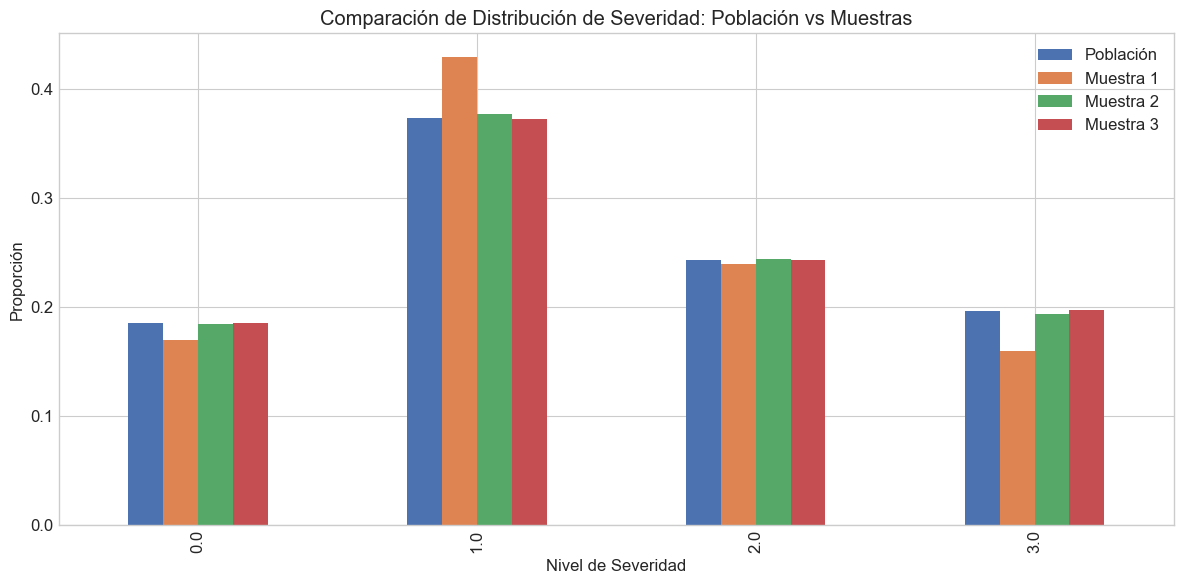

In [ ]:
try:
    # Distribución en la población
    severidad_pop = df['IR_29301_SEVERIDAD'].value_counts(normalize=True)

    # Distribuciones en las muestras
    severidad_m1 = muestra_1['IR_29301_SEVERIDAD'].value_counts(normalize=True)
    severidad_m2 = muestra_2['IR_29301_SEVERIDAD'].value_counts(normalize=True)
    severidad_m3 = muestra_3['IR_29301_SEVERIDAD'].value_counts(normalize=True)

    print("Distribución de Severidad (Población vs Muestras):")
    print("Población:")
    print(severidad_pop)
    print("\nMuestra 1 (pequeña):")
    print(severidad_m1)
    print("\nMuestra 2 (1%):")
    print(severidad_m2)
    print("\nMuestra 3 (5%):")
    print(severidad_m3)

    # Visualizamos la comparación
    plt.figure(figsize=(14, 7))

    # Organizamos los datos para la visualización
    all_data = pd.DataFrame({
        'Población': severidad_pop,
        'Muestra 1': severidad_m1,
        'Muestra 2': severidad_m2,
        'Muestra 3': severidad_m3
    })

    # Rellenamos NaN con ceros
    all_data = all_data.fillna(0)

    # Graficamos
    all_data.plot(kind='bar')
    plt.title('Comparación de Distribución de Severidad: Población vs Muestras')
    plt.xlabel('Nivel de Severidad')
    plt.ylabel('Proporción')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error al analizar la severidad: {e}")

### 4.2 Muestreo Estratificado

El muestreo estratificado divide la población en grupos homogéneos (estratos) y luego selecciona muestras aleatorias de cada estrato en proporción a su tamaño en la población. Esta técnica es especialmente útil cuando hay subgrupos importantes que deben estar representados adecuadamente en la muestra.

En el contexto de los datos GRD, podemos estratificar por variables como sexo, grupos etarios, o nivel de severidad.

Estratificación por Sexo:
SEXO
MUJER          612203
HOMBRE         427345
DESCONOCIDO        39
Name: count, dtype: int64

Número de muestras por sexo:
SEXO
MUJER          30609
HOMBRE         21367
DESCONOCIDO        1
Name: count, dtype: int64

Tamaño de la muestra estratificada: 51977
Distribución por sexo en la muestra estratificada:
SEXO
MUJER          0.588895
HOMBRE         0.411086
DESCONOCIDO    0.000019
Name: proportion, dtype: float64


<Figure size 1000x600 with 0 Axes>

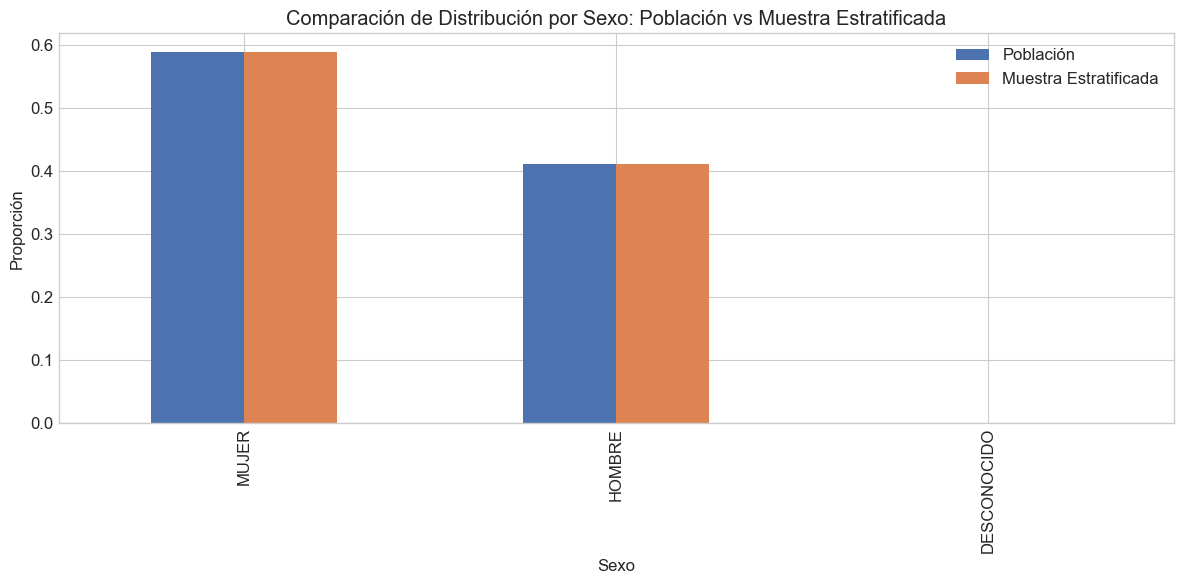

In [ ]:
try:
    # Estrato: Sexo
    print("Estratificación por Sexo:")
    sexo_counts = df['SEXO'].value_counts()
    print(sexo_counts)

    # Calculamos la proporción de cada estrato en la población
    sexo_prop = sexo_counts / sexo_counts.sum()

    # Definimos un tamaño de muestra del 5% de la población
    tam_muestra_estrat = int(0.05 * n_poblacion)

    # Calculamos cuántos ejemplos tomar de cada estrato
    muestras_por_sexo = (sexo_prop * tam_muestra_estrat).astype(int)
    print("\nNúmero de muestras por sexo:")
    print(muestras_por_sexo)

    # Tomamos las muestras estratificadas
    muestra_estrat = pd.DataFrame()
    for sexo, n in muestras_por_sexo.items():
        estrato = df[df['SEXO'] == sexo]
        muestra_sexo = estrato.sample(n=min(n, len(estrato)), random_state=42)
        muestra_estrat = pd.concat([muestra_estrat, muestra_sexo])

    print(f"\nTamaño de la muestra estratificada: {len(muestra_estrat)}")
    print("Distribución por sexo en la muestra estratificada:")
    print(muestra_estrat['SEXO'].value_counts(normalize=True))

    # Visualizamos la comparación
    plt.figure(figsize=(10, 6))
    sexo_comp = pd.DataFrame({
        'Población': df['SEXO'].value_counts(normalize=True),
        'Muestra Estratificada': muestra_estrat['SEXO'].value_counts(normalize=True)
    })
    sexo_comp.plot(kind='bar')
    plt.title('Comparación de Distribución por Sexo: Población vs Muestra Estratificada')
    plt.xlabel('Sexo')
    plt.ylabel('Proporción')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error al realizar muestreo estratificado: {e}")

### 4.3 Muestreo Sistemático

El muestreo sistemático selecciona elementos a intervalos regulares después de un punto de inicio aleatorio. Esta técnica es simple de implementar y puede ser más eficiente que el muestreo aleatorio simple en algunas situaciones.

“Elijo un punto al azar y luego tomo cada k elementos.”

Imagina una lista de pacientes:

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12...


1️⃣ Eliges un punto de inicio al azar

Ej: empiezas en el paciente 3

2️⃣ Defines un intervalo (k)

Ej: cada 3 pacientes

3️⃣ Seleccionas siguiendo el patrón

👉 Resultado:

3, 6, 9, 12...

In [ ]:
df.head()

,COD_HOSPITAL,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,SERVICIO_SALUD,TIPO_INGRESO,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,TIPO_FECHA_NACIMIENTO,TIPO_FECHA_INGRESO,TIPO_FECHAALTA,EDAD,DIAS_ESTANCIA
0,122100,72196813,HOMBRE,1980-04-13,VALDIVIA,URGENCIA,2023-03-12,2023-03-14,DOMICILIO,K35.3,064161,0.7094,1.0,1.0,YMD,DMY,DMY,43,2
1,114101,DESCONOCIDO,HOMBRE,2001-11-04,METROPOLITANO SURORIENTE,URGENCIA,2023-11-04,2023-11-10,DOMICILIO,J93.1,041301,1.0869,1.0,1.0,YMD,DMY,DMY,22,6
2,114101,97627974,HOMBRE,2020-07-30,METROPOLITANO SURORIENTE,URGENCIA,2023-06-07,2023-06-08,HOSPITALIZACIÓN DOMICILIARIA,J12.1,044161,0.4084,1.0,1.0,YMD,DMY,DMY,3,1
3,106103,67770674,MUJER,1978-11-14,VALPARAISO SAN ANTONIO,PROGRAMADA,2023-05-25,2023-05-26,DOMICILIO,N39.3,131301,0.6406,1.0,1.0,YMD,DMY,DMY,45,1
4,106103,100390800,MUJER,2023-12-20,VALPARAISO SAN ANTONIO,URGENCIA,2023-12-28,2023-12-30,DOMICILIO,R17,074131,0.5346,1.0,1.0,YMD,DMY,DMY,0,2


In [ ]:
df.TIPO_INGRESO.value_counts(normalize=True)

TIPO_INGRESO
URGENCIA       0.498885
PROGRAMADA     0.352420
OBSTETRICA     0.148643
DESCONOCIDO    0.000053
Name: proportion, dtype: float64

In [ ]:
df[df["TIPO_INGRESO"]=='URGENCIA'].IR_29301_SEVERIDAD.value_counts(normalize=True)

IR_29301_SEVERIDAD
1.0    0.353484
3.0    0.336985
2.0    0.298488
0.0    0.011043
Name: proportion, dtype: float64

In [ ]:
df[(df["TIPO_INGRESO"]=='URGENCIA') & (df["IR_29301_SEVERIDAD"]==1)].IR_29301_MORTALIDAD.value_counts(normalize=True)

IR_29301_MORTALIDAD
1.0    0.920581
2.0    0.074346
3.0    0.005073
Name: proportion, dtype: float64

In [ ]:
df.IR_29301_MORTALIDAD.value_counts(normalize=True)

IR_29301_MORTALIDAD
1.0    0.490764
0.0    0.186185
3.0    0.163354
2.0    0.159697
Name: proportion, dtype: float64

In [ ]:
df[df["IR_29301_MORTALIDAD"]==1].IR_29301_SEVERIDAD.value_counts(normalize=True)

IR_29301_SEVERIDAD
1.0    0.716447
2.0    0.254714
3.0    0.028839
Name: proportion, dtype: float64

In [ ]:
# Calculando el tamaño total de la población
n_poblacion = len(df[(df["DIAS_ESTANCIA"] <= 30) & (df["DIAS_ESTANCIA"] > 0)])

print(f"Tamaño total de la población de datos: {n_poblacion}")

Tamaño total de la población de datos: 785747


In [ ]:
# Definimos el tamaño de muestra deseado (5% de la población)
tam_muestra_sist = int(0.05 * n_poblacion)

# Calculamos el intervalo (k)
k = n_poblacion // tam_muestra_sist

print(f"Para seleccionar aproximadamente {tam_muestra_sist} registros de {n_poblacion}:")
print(f"Se seleccionará 1 registro cada {k} registros")

Para seleccionar aproximadamente 39287 registros de 785747:
Se seleccionará 1 registro cada 20 registros


Tamaño de la muestra sistemática: 39288 registros

Estadísticas de Estancia Hospitalaria:
Media Población: 5.80 días
Media Muestra Sistemática: 5.51 días
Mediana Población: 2.00 días
Mediana Muestra Sistemática: 3.00 días


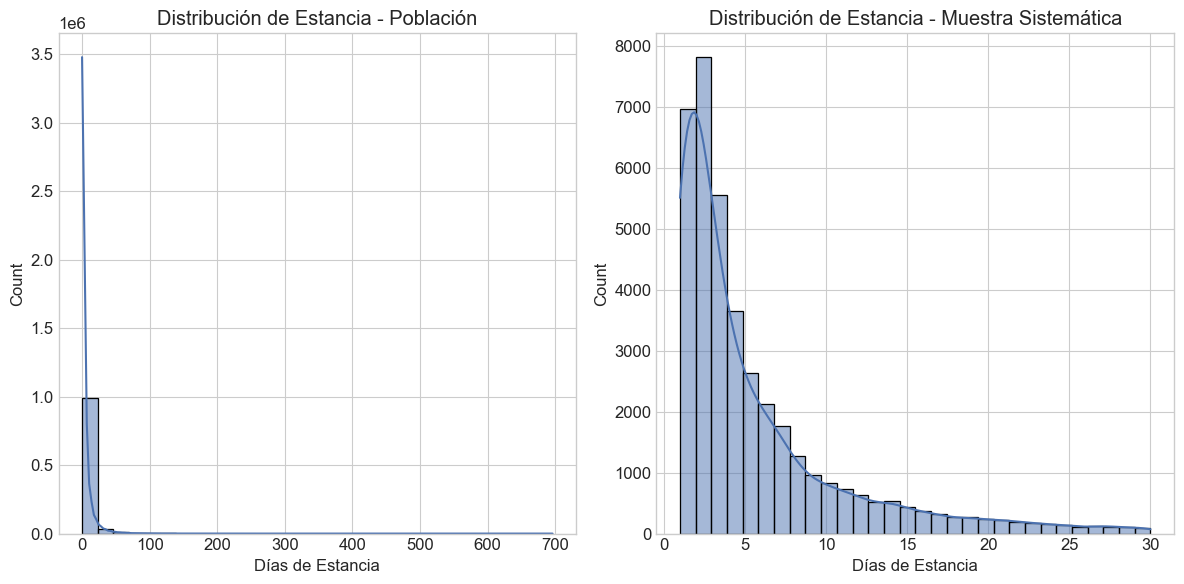

In [ ]:
try:
    # Reiniciamos el índice para facilitar la selección sistemática
    df_reset = df[(df["DIAS_ESTANCIA"] <= 30) & (df["DIAS_ESTANCIA"] > 0)].reset_index(drop=True)

    # Seleccionamos un punto de inicio aleatorio entre 0 y k-1
    np.random.seed(42)
    inicio = np.random.randint(0, k)

    # Seleccionamos los índices para la muestra sistemática
    indices_sistematicos = np.arange(inicio, n_poblacion, k)

    # Creamos la muestra sistemática
    muestra_sist = df_reset.iloc[indices_sistematicos]

    print(f"Tamaño de la muestra sistemática: {len(muestra_sist)} registros")

    # Comparamos algunas estadísticas entre la población y la muestra sistemática
    if 'DIAS_ESTANCIA' in df.columns and 'DIAS_ESTANCIA' in muestra_sist.columns:
        print("\nEstadísticas de Estancia Hospitalaria:")
        print(f"Media Población: {df['DIAS_ESTANCIA'].mean():.2f} días")
        print(f"Media Muestra Sistemática: {muestra_sist['DIAS_ESTANCIA'].mean():.2f} días")

        print(f"Mediana Población: {df['DIAS_ESTANCIA'].median():.2f} días")
        print(f"Mediana Muestra Sistemática: {muestra_sist['DIAS_ESTANCIA'].median():.2f} días")

        # Visualizamos la comparación de distribuciones
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        sns.histplot(df['DIAS_ESTANCIA'], kde=True, bins=30)
        plt.title('Distribución de Estancia - Población')
        plt.xlabel('Días de Estancia')

        plt.subplot(1, 2, 2)
        sns.histplot(muestra_sist['DIAS_ESTANCIA'], kde=True, bins=30)
        plt.title('Distribución de Estancia - Muestra Sistemática')
        plt.xlabel('Días de Estancia')

        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Error al realizar muestreo sistemático: {e}")

## 5. Error de muestreo y tamaño de muestra

El error de muestreo es la diferencia entre el valor estimado a partir de una muestra y el valor real en la población. A continuación, exploraremos cómo varía este error en función del tamaño de la muestra.

También analizaremos la precisión de las estimaciones mediante intervalos de confianza.

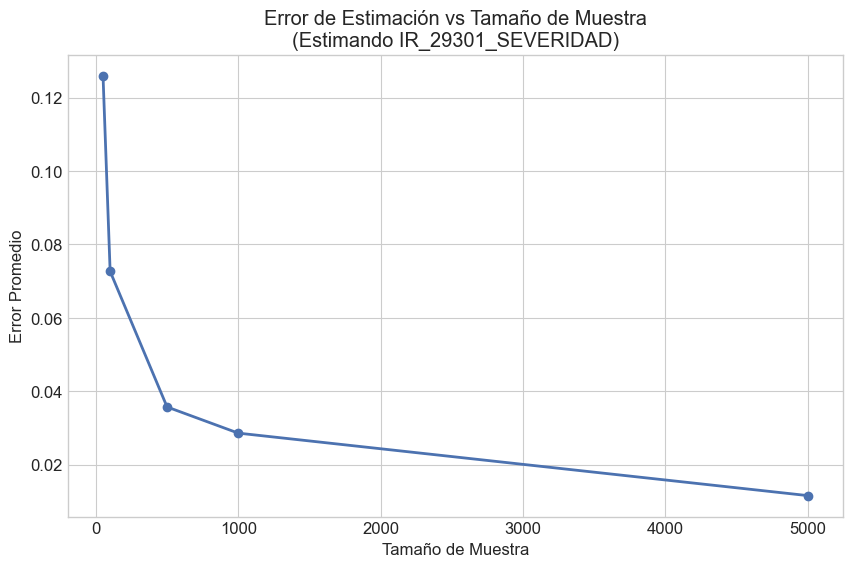

Valor poblacional de IR_29301_SEVERIDAD: 1.4502

Error promedio por tamaño de muestra:
Muestra de 50 elementos: Error = 0.1260 (8.69%)
Muestra de 100 elementos: Error = 0.0726 (5.01%)
Muestra de 500 elementos: Error = 0.0357 (2.46%)
Muestra de 1000 elementos: Error = 0.0286 (1.97%)
Muestra de 5000 elementos: Error = 0.0116 (0.80%)

Ejemplos de intervalos de confianza (95%):
Muestra de 50 elementos: [1.1325, 1.7875] - Contiene el valor poblacional
Muestra de 100 elementos: [1.2880, 1.7320] - Contiene el valor poblacional
Muestra de 500 elementos: [1.3783, 1.5617] - Contiene el valor poblacional
Muestra de 1000 elementos: [1.3854, 1.5126] - Contiene el valor poblacional
Muestra de 5000 elementos: [1.4178, 1.4742] - Contiene el valor poblacional


In [ ]:
# Definimos diferentes tamaños de muestra
tamanios_muestra = [50, 100, 500, 1000, 5000]
if n_poblacion < 5000:
    tamanios_muestra = [min(50, n_poblacion//10), min(100, n_poblacion//5), min(500, n_poblacion//2)]

# Evaluamos cómo varía el error de estimación según el tamaño de muestra
try:
    # Variable a estimar: severidad promedio
    if 'IR_29301_SEVERIDAD' in df.columns:
        variable_estudio = 'IR_29301_SEVERIDAD'
        valor_poblacional = df[variable_estudio].mean()

        errores = []
        intervalos_conf = []

        # Para cada tamaño de muestra, calculamos el error
        for tam in tamanios_muestra:
            tam = min(tam, n_poblacion)  # Nos aseguramos que no supere el tamaño de la población
            errores_tam = []

            # Realizamos 30 simulaciones para cada tamaño
            for _ in range(30):
                muestra = df.sample(n=tam, random_state=_ + 100)
                estimacion = muestra[variable_estudio].mean()
                error = abs(estimacion - valor_poblacional)
                errores_tam.append(error)

                # Calculamos el intervalo de confianza para esta muestra (95%)
                sem = muestra[variable_estudio].std() / np.sqrt(tam)
                intervalo = (estimacion - 1.96 * sem, estimacion + 1.96 * sem)
                intervalos_conf.append((tam, intervalo))

            errores.append((tam, np.mean(errores_tam)))

        # Visualizamos los resultados
        tam_muestras, error_promedio = zip(*errores)

        plt.figure(figsize=(10, 6))
        plt.plot(tam_muestras, error_promedio, 'o-', linewidth=2)
        plt.title(f'Error de Estimación vs Tamaño de Muestra\n(Estimando {variable_estudio})')
        plt.xlabel('Tamaño de Muestra')
        plt.ylabel('Error Promedio')
        plt.grid(True)
        plt.show()

        # Mostramos los resultados numéricos
        print(f"Valor poblacional de {variable_estudio}: {valor_poblacional:.4f}")
        print("\nError promedio por tamaño de muestra:")
        for tam, error in errores:
            print(f"Muestra de {tam} elementos: Error = {error:.4f} ({error/valor_poblacional:.2%})")

        # Mostramos información sobre los intervalos de confianza
        print("\nEjemplos de intervalos de confianza (95%):")
        for i, (tam, intervalo) in enumerate(intervalos_conf):
            if i % 30 == 0:  # Mostramos solo el primer intervalo de cada tamaño
                contiene = intervalo[0] <= valor_poblacional <= intervalo[1]
                print(f"Muestra de {tam} elementos: [{intervalo[0]:.4f}, {intervalo[1]:.4f}] - " +
                      ("Contiene" if contiene else "No contiene") + " el valor poblacional")
    else:
        print("La variable de severidad no está disponible en el dataframe para este análisis.")
except Exception as e:
    print(f"Error al calcular errores de muestreo: {e}")

## 6. Consideraciones especiales para el muestreo en datos GRD

Los datos de Grupos Relacionados por Diagnóstico (GRD) tienen características particulares que deben tenerse en cuenta al aplicar técnicas de muestreo:

1. **Heterogeneidad**: Los datos GRD son inherentemente heterogéneos debido a la variedad de diagnósticos, procedimientos y niveles de severidad. El muestreo estratificado suele ser más adecuado que el muestreo aleatorio simple.

2. **Variables clave para estratificación**:
   - Sexo
   - Grupos etarios
   - Nivel de severidad
   - Tipo de GRD
   - Hospital o servicio de salud

3. **Estructura jerárquica**: Los pacientes están anidados dentro de hospitales, lo que puede requerir técnicas de muestreo por conglomerados o muestreo multinivel.

4. **Eventos raros**: Algunos GRD o complicaciones pueden ser muy poco frecuentes pero clínicamente importantes. El muestreo estratificado o sobremuestreo puede ser necesario para asegurar su representación.

5. **Estacionalidad**: Algunos diagnósticos tienen patrones estacionales. Si es relevante para el análisis, el muestreo debe considerar diferentes periodos del año.

6. **Variación en costos**: La distribución de costos en datos GRD suele ser asimétrica, con una pequeña proporción de casos que representan una gran proporción de los costos totales. El muestreo estratificado por grupos de costo puede ser apropiado.

## 7. Conclusiones y recomendaciones

El muestreo estadístico es una herramienta poderosa para el análisis de conjuntos de datos grandes como los registros GRD. Permite:

1. Reducir el tiempo y recursos de procesamiento
2. Obtener estimaciones precisas de parámetros poblacionales
3. Facilitar análisis exploratorios y desarrollo de modelos

Sin embargo, es crucial:
- Seleccionar la técnica de muestreo apropiada según los objetivos
- Verificar la representatividad de las muestras
- Considerar el error de estimación al interpretar resultados

### Recomendaciones para datos GRD

1. Para análisis descriptivos generales, utilizar muestreo estratificado por variables como nivel de severidad, tipo de GRD y hospital.
2. Para análisis de costos, considerar estratificación por nivel de costo o sobremuestreo de casos de alto costo.
3. Evaluar la representatividad de las muestras comparando distribuciones de variables clave.
4. Para datos con estructura jerárquica, considerar muestreo por conglomerados o técnicas de muestreo multinivel.
5. Documentar detalladamente la metodología de muestreo para asegurar la reproducibilidad de los resultados.

## 8. Ejercicios prácticos

1. Realice un muestreo estratificado utilizando múltiples variables (por ejemplo, sexo y nivel de severidad) y compare los resultados con un muestreo aleatorio simple.

2. Calcule intervalos de confianza para estimaciones de interés (como duración de estancia media o costo promedio) utilizando diferentes tamaños de muestra.

3. Explore el impacto de diferentes técnicas de muestreo en la precisión de modelos predictivos sencillos (por ejemplo, regresión lineal para predecir estancia hospitalaria).

4. Implemente un muestreo por conglomerados utilizando hospitales como unidades de muestreo y compare con otras técnicas.

5. Diseñe un esquema de muestreo óptimo para un análisis específico de interés en el contexto de datos GRD.